In [1]:
from astropy.io import fits
import numpy as np
from astropy import wcs
import astropy.units as u
import scipy.constants as cst
from astropy.stats import gaussian_fwhm_to_sigma
import astropy.convolution as conv
import datetime
import matplotlib.pyplot as plt

In [2]:
file = 'fits_and_hdf5/pySIDES_from_uchuu_tile_0_1.414deg_x_1.414deg_fir_lines_res20arcsec_dnu4.0GHz_full_de_Looze_smoothed_MJy_sr.fits'
cube = fits.getdata(file)
hdr = fits.getheader(file)
reso = (hdr['CDELT1'] * u.Unit(hdr["CUNIT1"]) )
pix_size =  (reso**2).to(u.sr).value 
cube *= pix_size *1e6 # MJy/sr --> Jy

map_area = pix_size * cube.shape[1] * cube.shape[2]

map_size = hdr['NAXIS1']
center = map_size // 2

noise = np.zeros((hdr['NAXIS3'], map_size, map_size))
for f in range(hdr['NAXIS3']): 
    noise_level = cube[f,:,:].sum()*pix_size / map_area #noise level in Jy/sr
    print(noise_level)
    # Add white Gaussian noise
    noise[f,:,:] += np.random.normal(loc=0.0, scale=noise_level, size=(map_size, map_size))

w = wcs.WCS(hdr)
#Telescope diameter 
D = 2 #m 

0.0061385192762154145
0.00618551724936365
0.006236980443338849
0.006298306468210429
0.00636070061000205
0.0064123120755963355
0.0064505240845906435
0.006510529536821215
0.006561649824558646
0.006620067975780029
0.006673608105734089
0.00671177438579213
0.006759679497047177
0.006822145364132738
0.006892072063158781
0.006946396322564878
0.006981032544946858
0.007038263307574055
0.007078397840054024
0.007120357897374173
0.007173491985609578
0.00722706098376238
0.0072738803939885206
0.007315965457074782
0.007366453892744733
0.007417573502258183
0.007459535221605334
0.007500081133944017
0.007541264048316574
0.007607984147594792
0.007641241566836147
0.007704069873822869
0.007729824743517856
0.007788411282419058
0.007842478144687392
0.007876749014738098
0.00792833306722375
0.00797629303598585
0.008008782360851983
0.008056276532146413
0.008093471081652148
0.008132953064003936
0.008176713646571375
0.008214927165456755
0.008263023111725819
0.008314041995024387
0.00835467295033423
0.00839612019519

res=15.08 arcsec


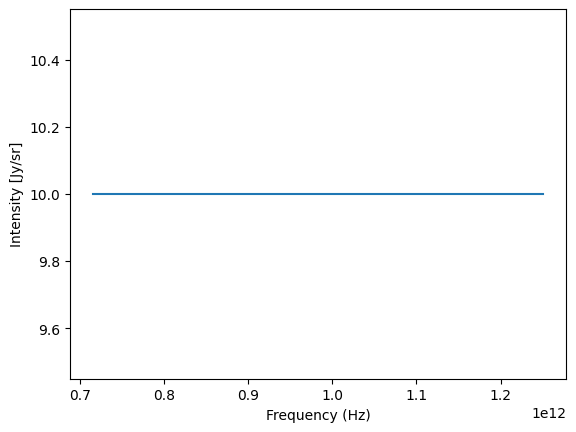

In [3]:
z = np.arange(hdr['NAXIS3'])
freq_list = ( w.swapaxes(0, 2).sub(1).wcs_pix2world(z, 0)[0] * u.Unit(hdr["CUNIT3"]) ).to(u.Hz).value
dnu = (hdr['CDELT3'] * u.Unit(hdr["CUNIT3"]) ).to(u.Hz).value
vdelt = dnu / freq_list * (cst.c*1e-3) #km/sec
fwhm = 1.22 * cst.c / (freq_list * D) * u.rad
sigma = fwhm * gaussian_fwhm_to_sigma
#Omega_beam = (2*np.pi*(sigma)**2).to(u.sr)
res = fwhm.min() / 2
sigma_pix_list = sigma / res

intensity = (res**2).to(u.sr).value*10*vdelt #Jy.km/s

plt.plot(freq_list, intensity / (res**2).to(u.sr).value / vdelt)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Intensity [Jy/sr]')
print(f'res={res.to(u.arcsec):.2f}')


In [4]:
for factor_on_Sigma in (1,1.5,2,2.5): 
            
    cube_1_source = np.zeros((hdr['NAXIS3'], map_size, map_size))
    cube_1_source += noise
    cube_1_source[:, center, center] += intensity / (res**2).to(u.sr).value / vdelt  #Jy/sr

    for f, sigma_pix in enumerate(sigma_pix_list):

        kernel_channel = conv.Gaussian2DKernel(x_stddev=sigma_pix * factor_on_Sigma, x_size=map_size)
        kernel_channel.normalize(mode="peak")
        #size of the beam in pix2
        beam_area_pix2 = np.sum(kernel_channel.array)
        cube_1_source[f] = conv.convolve_fft(cube_1_source[f], kernel_channel, normalize_kernel=True, boundary = 'wrap')

    hdr_out = hdr.copy()
    hdr_out['CDELT2'] = res.to(u.deg).value
    hdr_out['CDELT1'] = res.to(u.deg).value
    hdr_out["DATE"]  = str(datetime.datetime.now())
    hdr_out["BUNIT"] = "Jy/sr"
    hdr_out['CRPIX1'] = center
    hdr_out['CRPIX2'] = center

    # Create HDU and save
    hdu = fits.PrimaryHDU(cube_1_source, header=hdr_out)
    hdul = fits.HDUList([hdu])
    path = '/home/mvancuyck/Desktop/TIM_analysis/namap/fits_and_hdf5/'
    savepath = f'cube_1source_with_{factor_on_Sigma}xbigger_sigma_PSF.fits'
    hdul.writeto(path+savepath, overwrite=True)
    print("saved ", path+savepath)
    print('')

    for separation_in_pix in (10,15,20,25):
             
        cube_2_source = np.zeros((hdr['NAXIS3'], map_size, map_size))
        cube_2_source += noise
        cube_2_source[:, center, center-separation_in_pix//2] += intensity / (res**2).to(u.sr).value / vdelt
        cube_2_source[:, center, center+separation_in_pix//2] += intensity / (res**2).to(u.sr).value / vdelt

        for f, sigma_pix in enumerate(sigma_pix_list):

            kernel_channel = conv.Gaussian2DKernel(x_stddev=sigma_pix * factor_on_Sigma, x_size=map_size)
            kernel_channel.normalize(mode="peak")
            #size of the beam in pix2
            beam_area_pix2 = np.sum(kernel_channel.array)
            cube_2_source[f] = conv.convolve_fft(cube_2_source[f], kernel_channel, normalize_kernel=True, boundary = 'wrap')

        # Create HDU and save
        hdu = fits.PrimaryHDU(cube_2_source, header=hdr_out)
        hdul = fits.HDUList([hdu])

        path = '/home/mvancuyck/Desktop/TIM_analysis/namap/fits_and_hdf5/'
        savepath = path+f'cube_2sources_separated_by_{res.to(u.arcsec).value*separation_in_pix:.1f}arcsecs_with_{factor_on_Sigma}xbigger_sigma_PSF.fits'
        hdul.writeto(savepath, overwrite=True)
        
        print("saved ",savepath)

saved  /home/mvancuyck/Desktop/TIM_analysis/namap/fits_and_hdf5/cube_1source_with_1xbigger_sigma_PSF.fits

saved  /home/mvancuyck/Desktop/TIM_analysis/namap/fits_and_hdf5/cube_2sources_separated_by_150.8arcsecs_with_1xbigger_sigma_PSF.fits
saved  /home/mvancuyck/Desktop/TIM_analysis/namap/fits_and_hdf5/cube_2sources_separated_by_226.1arcsecs_with_1xbigger_sigma_PSF.fits
saved  /home/mvancuyck/Desktop/TIM_analysis/namap/fits_and_hdf5/cube_2sources_separated_by_301.5arcsecs_with_1xbigger_sigma_PSF.fits
saved  /home/mvancuyck/Desktop/TIM_analysis/namap/fits_and_hdf5/cube_2sources_separated_by_376.9arcsecs_with_1xbigger_sigma_PSF.fits
saved  /home/mvancuyck/Desktop/TIM_analysis/namap/fits_and_hdf5/cube_1source_with_1.5xbigger_sigma_PSF.fits

saved  /home/mvancuyck/Desktop/TIM_analysis/namap/fits_and_hdf5/cube_2sources_separated_by_150.8arcsecs_with_1.5xbigger_sigma_PSF.fits
saved  /home/mvancuyck/Desktop/TIM_analysis/namap/fits_and_hdf5/cube_2sources_separated_by_226.1arcsecs_with_1.5xbigg